# ChemBL Model Analysis Notebook

This notebook loads a trained ChemBL model and analyzes its performance across all targets, including ROC curves and other metrics.

## Setup
Make sure you have the trained model checkpoint available.

In [67]:
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import pytorch_lightning as pl
from pathlib import Path
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix
from sklearn.preprocessing import label_binarize

# Optional imports for interactive plots
try:
    import plotly.graph_objects as go
    import plotly.express as px
    from plotly.subplots import make_subplots
    PLOTLY_AVAILABLE = True
    print("Plotly is available - interactive plots will be shown")
except ImportError:
    PLOTLY_AVAILABLE = False
    print("Plotly not available - using matplotlib only")

# Suppress warnings
warnings.filterwarnings('ignore')

# Add project root to path
project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))

from mole.models.chembl_model import ChemBLModel
from mole.models.chembl_lightning import ChemBLLightningModule
from scripts.pretraining_mlm.run_chembl_unified import ChemBLCSVDataModule, ChemBLCSVDataset

print(f"Project root: {project_root}")
print(f"Python version: {sys.version}")
print(f"PyTorch version: {torch.__version__}")
print(f"PyTorch Lightning version: {pl.__version__}")

Plotly is available - interactive plots will be shown
Project root: /home/mschauperl/mole_public
Python version: 3.10.18 (main, Jun  5 2025, 13:14:17) [GCC 11.2.0]
PyTorch version: 2.6.0+cu124
PyTorch Lightning version: 2.5.2


## Configuration

Set the paths to your trained model and data.

In [68]:
# Configuration
CHECKPOINT_PATH = "outputs/chembl_csv_filtered_corrected/chembl_csv_filtered_corrected_model/best_model.ckpt"
CSV_PATH = "../../examples_data_creation/chembl_single_target/chembl_multi_target_dataset.csv"
INPUT_VOCAB_PATH = "../../mole/data/vocabularies/vocabulary_radius0_structural_guacamol_v1.pkl"
TARGET_VOCAB_PATH = "../../mole/data/vocabularies/vocabulary_radius1_functional_guacamol_v1.pkl"

# Check if files exist
print("Checking file paths:")
print(f"Checkpoint exists: {Path(CHECKPOINT_PATH).exists()}")
print(f"CSV exists: {Path(CSV_PATH).exists()}")
print(f"Input vocab exists: {Path(INPUT_VOCAB_PATH).exists()}")
print(f"Target vocab exists: {Path(TARGET_VOCAB_PATH).exists()}")

Checking file paths:
Checkpoint exists: True
CSV exists: True
Input vocab exists: True
Target vocab exists: True


## Load the Trained Model

In [69]:
# Load the checkpoint
checkpoint = torch.load(CHECKPOINT_PATH, map_location='cpu')
print(f"Checkpoint keys: {list(checkpoint.keys())}")
print(f"Model state dict keys: {list(checkpoint['state_dict'].keys())[:10]}...")

# Extract hyperparameters
hyperparams = checkpoint.get('hyper_parameters', {})
print(f"\nHyperparameters:")
for key, value in hyperparams.items():
    print(f"  {key}: {value}")

Checkpoint keys: ['epoch', 'global_step', 'pytorch-lightning_version', 'state_dict', 'loops', 'callbacks', 'optimizer_states', 'lr_schedulers', 'MixedPrecision']
Model state dict keys: ['model.encoder.embeddings.word_embeddings.weight', 'model.encoder.embeddings.token_type_embeddings.weight', 'model.encoder.embeddings.LayerNorm.weight', 'model.encoder.embeddings.LayerNorm.bias', 'model.encoder.encoder.layer.0.attention.self.query_proj.weight', 'model.encoder.encoder.layer.0.attention.self.query_proj.bias', 'model.encoder.encoder.layer.0.attention.self.key_proj.weight', 'model.encoder.encoder.layer.0.attention.self.key_proj.bias', 'model.encoder.encoder.layer.0.attention.self.value_proj.weight', 'model.encoder.encoder.layer.0.attention.self.value_proj.bias']...

Hyperparameters:


In [70]:
# First, we need to create the model and data module to get the required parameters
print("Creating data module to get model parameters...")
data_module = ChemBLCSVDataModule(
    csv_path=CSV_PATH,
    input_vocab_path=INPUT_VOCAB_PATH,
    target_vocab_path=TARGET_VOCAB_PATH,
    batch_size=32,
    num_workers=4,
    enable_masking=False,
    use_fold_splits=True,
    test_fold=0,
    input_radius=0,
    target_radius=1,
    target_use_features=False,
    max_length=256,
)

# Setup to get vocabulary sizes and target info
data_module.setup('test')
test_dataset = data_module.test_dataset

# Get vocabulary sizes and target info directly from test dataset
vocab_sizes = {
    'input_vocab_size': test_dataset.input_vocab_size,
    'target_vocab_size': test_dataset.target_vocab_size,
}
target_info = {
    'num_targets': test_dataset.num_targets,
    'target_names': test_dataset.target_names,
}

print(f"Vocabulary sizes: {vocab_sizes}")
print(f"Target info: {target_info}")

# Create model configuration that matches the checkpoint
# From the error, the checkpoint was trained with:
# - type_vocab_size: 1 (not 2)
# - max_relative_positions: 128 (not -1 which becomes 1024)
model_config = {
    "hidden_size": 512,
    "num_hidden_layers": 8,
    "num_attention_heads": 8,
    "intermediate_size": 2048,
    "hidden_dropout_prob": 0.1,
    "attention_probs_dropout_prob": 0.1,
    "max_position_embeddings": 512,
    "type_vocab_size": 1,  # Changed from 2 to 1 to match checkpoint
    "initializer_range": 0.02,
    "layer_norm_eps": 1e-7,
    "relative_attention": True,
    "max_relative_positions": 64,  # Changed to 64 (checkpoint has rel_embeddings 128x512 = 2*64)
    "pad_token_id": 0,
    "bos_token_id": 1,
    "eos_token_id": 2,
    "position_biased_input": False,
    "pos_att_type": "p2c|c2p",
    "norm_rel_ebd": "layer_norm",
    "hidden_act": "gelu",
    "attention_head_type": "disentangled",
    "classifier_dropout": 0.1,
}

# Create the model
model = ChemBLModel(
    deberta_config=model_config,
    input_vocab_size=vocab_sizes['input_vocab_size'],
    target_vocab_size=vocab_sizes['target_vocab_size'],
    num_targets=target_info['num_targets'],
    hidden_dropout_prob=0.1,
    classifier_dropout_prob=0.1,
)

# Create the Lightning module
lightning_module = ChemBLLightningModule(
    model=model,
    optimizer_cfg={
        'optimizer': 'AdamW',
        'lr': 1e-4,
        'weight_decay': 0.01,
        'lr_scheduler': 'LambdaLR',
        'warmup_steps': 1000,
    },
    mlm_loss_weight=0.0,  # No MLM for evaluation
    classification_loss_weight=1.0,
    log_predictions=False,
    log_target_metrics=True,
    max_targets_to_log=10,
)

# Load the checkpoint weights
print("Loading checkpoint weights...")
lightning_module.load_state_dict(checkpoint['state_dict'], strict=False)

# Get the model and set to eval mode
model = lightning_module.model
model.eval()

print(f"Model loaded successfully")
print(f"Model type: {type(model)}")
print(f"Number of targets: {model.num_targets}")

Creating data module to get model parameters...
Loading data from ../../examples_data_creation/chembl_single_target/chembl_multi_target_dataset.csv


Loaded 212637 compounds from CSV
Found 7 activity columns: ['activity_CHEMBL1614161', 'activity_CHEMBL1614441', 'activity_CHEMBL1614458', 'activity_CHEMBL1614530', 'activity_CHEMBL1738442', 'activity_CHEMBL1794345', 'activity_CHEMBL1794580']
Using fold column: ['fold_1' 'fold_0' 'fold_2']
Creating fold-based splits (using fold_0 as validation)
Train: 147639, Validation: 32499, Test: 32499
CrossEnvMolDataset initialized:
  Input vocab: 173 tokens (radius=0, features=False)
  Target vocab: 1472 tokens (radius=1, features=False)
  Masking: 15.0% prob, 80.0% [MASK], 10.0% random
Loaded ChemBL CSV dataset: 32499 compounds, 7 targets
  activity_CHEMBL1614161: 2131 active, 2346 inactive, 28022 missing
  activity_CHEMBL1614441: 1900 active, 1669 inactive, 28930 missing
  activity_CHEMBL1614458: 2816 active, 5815 inactive, 23868 missing
  activity_CHEMBL1614530: 2864 active, 4502 inactive, 25133 missing
  activity_CHEMBL1738442: 4851 active, 1713 inactive, 25935 missing
  activity_CHEMBL1794345

## Load Test Data

In [71]:
# Get test dataset and loader
test_loader = data_module.test_dataloader()

print(f"Test dataset size: {len(test_dataset)}")
print(f"Number of targets: {test_dataset.num_targets}")
print(f"Target names: {test_dataset.target_names}")

Test dataset size: 32499
Number of targets: 7
Target names: ['activity_CHEMBL1614161', 'activity_CHEMBL1614441', 'activity_CHEMBL1614458', 'activity_CHEMBL1614530', 'activity_CHEMBL1738442', 'activity_CHEMBL1794345', 'activity_CHEMBL1794580']


## Generate Predictions

In [72]:
# Generate predictions
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

all_predictions = []
all_targets = []
all_masks = []

print(f"Using device: {device}")
print("Generating predictions...")

with torch.no_grad():
    for batch_idx, batch in enumerate(test_loader):
        if batch_idx % 100 == 0:
            print(f"Processing batch {batch_idx}/{len(test_loader)}")
        
        # Move batch to device
        batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}
        
        # Debug: print batch keys and shapes to see what's available
        if batch_idx == 0:
            print(f"Batch keys: {list(batch.keys())}")
            print(f"original_input shape: {batch['original_input'].shape}")
            print(f"original_input dtype: {batch['original_input'].dtype}")
            print(f"chembl_targets shape: {batch['chembl_targets'].shape}")
            print(f"chembl_mask shape: {batch['chembl_mask'].shape}")
        
        # Get predictions - handle variable-length sequences properly
        # In PyTorch Geometric, molecules with different lengths are concatenated
        # We need to use the 'batch' tensor to separate them back and pad to the same length
        original_input = batch['original_input']
        batch_indices = batch['batch']  # This tells us which molecule each token belongs to
        
        # Extract scalar values from the tensors
        num_targets = batch['num_targets'][0].item()  # Get the first element and convert to Python int
        real_batch_size = batch['chembl_targets'].shape[0] // num_targets
        
        if batch_idx == 0:
            print(f"num_targets: {num_targets}")
            print(f"real_batch_size: {real_batch_size}")
            print(f"batch_indices shape: {batch_indices.shape}")
            print(f"batch_indices unique: {torch.unique(batch_indices)}")
        
        # Convert variable-length sequences to fixed-length by padding
        from torch.nn.utils.rnn import pad_sequence
        
        # Group tokens by molecule
        molecule_sequences = []
        for mol_idx in range(real_batch_size):
            mol_mask = (batch_indices == mol_idx)
            mol_tokens = original_input[mol_mask]
            molecule_sequences.append(mol_tokens)
        
        # Pad sequences to the same length
        padded_input = pad_sequence(molecule_sequences, batch_first=True, padding_value=0)
        
        if batch_idx == 0:
            print(f"Individual sequence lengths: {[len(seq) for seq in molecule_sequences[:5]]}...")  # Show first 5
            print(f"Padded input shape: {padded_input.shape}")
        
        # Reshape chembl_targets and chembl_mask to [batch_size, num_targets]
        chembl_targets = batch['chembl_targets'].view(real_batch_size, num_targets)
        chembl_mask = batch['chembl_mask'].view(real_batch_size, num_targets)
        
        if batch_idx == 0:
            print(f"Reshaped chembl_targets shape: {chembl_targets.shape}")
            print(f"Reshaped chembl_mask shape: {chembl_mask.shape}")
        
        # Create attention mask (1 for real tokens, 0 for padding)
        attention_mask = torch.zeros_like(padded_input)
        for mol_idx, seq in enumerate(molecule_sequences):
            attention_mask[mol_idx, :len(seq)] = 1
        
        if batch_idx == 0:
            print(f"Attention mask shape: {attention_mask.shape}")
        
        outputs = model(
            input_ids=padded_input,
            input_mask=attention_mask,
            chembl_targets=chembl_targets,
            chembl_mask=chembl_mask,
            relative_pos=batch.get('relative_pos', None)
        )
        # For classification, we get logits for [batch, num_targets, 2] and take the probability of active class
        classification_logits = outputs['classification_logits']  # [batch, num_targets, 2]
        predictions = torch.softmax(classification_logits, dim=-1)[:, :, 1]  # [batch, num_targets] - prob of active
        
        # Store results
        all_predictions.append(predictions.cpu())
        all_targets.append(chembl_targets.cpu())
        all_masks.append(chembl_mask.cpu())

# Concatenate all batches
all_predictions = torch.cat(all_predictions, dim=0)
all_targets = torch.cat(all_targets, dim=0)
all_masks = torch.cat(all_masks, dim=0)

print(f"Predictions shape: {all_predictions.shape}")
print(f"Targets shape: {all_targets.shape}")
print(f"Masks shape: {all_masks.shape}")

Using device: cuda
Generating predictions...


Processing batch 0/1016
Batch keys: ['x', 'edge_index', 'edge_attr', 'labels', 'original_input', 'target_tokens', 'smiles', 'chembl_targets', 'chembl_mask', 'num_targets', 'batch', 'ptr']
original_input shape: torch.Size([701])
original_input dtype: torch.int64
chembl_targets shape: torch.Size([224])
chembl_mask shape: torch.Size([224])
num_targets: 7
real_batch_size: 32
batch_indices shape: torch.Size([701])
batch_indices unique: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31],
       device='cuda:0')
Individual sequence lengths: [19, 23, 22, 15, 33]...
Padded input shape: torch.Size([32, 35])
Reshaped chembl_targets shape: torch.Size([32, 7])
Reshaped chembl_mask shape: torch.Size([32, 7])
Attention mask shape: torch.Size([32, 35])
Processing batch 100/1016
Processing batch 200/1016
Processing batch 300/1016
Processing batch 400/1016
Processing batch 500/1016
Processing batch 600/1016
Proc

## Calculate Metrics for Each Target

In [73]:
# Calculate metrics for each target
target_metrics = {}
target_names = test_dataset.target_names

for i, target_name in enumerate(target_names):
    print(f"\nAnalyzing target {i+1}/{len(target_names)}: {target_name}")
    
    # Get predictions and targets for this target
    preds = all_predictions[:, i]
    targets = all_targets[:, i]
    masks = all_masks[:, i]
    
    # Filter to only measured compounds
    measured_mask = masks.bool()
    if measured_mask.sum() == 0:
        print(f"  No measured compounds for {target_name}")
        continue
    
    preds_measured = preds[measured_mask]
    targets_measured = targets[measured_mask]
    
    # Convert targets to binary (1=active, -1=inactive -> 1=active, 0=inactive)
    targets_binary = (targets_measured == 1).float()
    
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(targets_binary, preds_measured)
    roc_auc = auc(fpr, tpr)
    
    # Calculate other metrics
    predictions_binary = (preds_measured > 0.5).float()
    
    # Count classes
    n_active = (targets_binary == 1).sum().item()
    n_inactive = (targets_binary == 0).sum().item()
    
    # Store metrics
    target_metrics[target_name] = {
        'fpr': fpr,
        'tpr': tpr,
        'thresholds': thresholds,
        'roc_auc': roc_auc,
        'predictions': preds_measured.numpy(),
        'targets': targets_binary.numpy(),
        'n_active': n_active,
        'n_inactive': n_inactive,
        'n_total': len(targets_binary),
    }
    
    print(f"  Active: {n_active}, Inactive: {n_inactive}, Total: {len(targets_binary)}")
    print(f"  ROC AUC: {roc_auc:.4f}")


Analyzing target 1/7: activity_CHEMBL1614161
  Active: 2131, Inactive: 2346, Total: 4477
  ROC AUC: 0.5556

Analyzing target 2/7: activity_CHEMBL1614441
  Active: 1900, Inactive: 1669, Total: 3569
  ROC AUC: 0.5765

Analyzing target 3/7: activity_CHEMBL1614458
  Active: 2816, Inactive: 5815, Total: 8631
  ROC AUC: 0.5444

Analyzing target 4/7: activity_CHEMBL1614530
  Active: 2864, Inactive: 4502, Total: 7366
  ROC AUC: 0.5605

Analyzing target 5/7: activity_CHEMBL1738442
  Active: 4851, Inactive: 1713, Total: 6564
  ROC AUC: 0.7033

Analyzing target 6/7: activity_CHEMBL1794345
  Active: 3337, Inactive: 8768, Total: 12105
  ROC AUC: 0.6982

Analyzing target 7/7: activity_CHEMBL1794580
  Active: 2803, Inactive: 6539, Total: 9342
  ROC AUC: 0.8276


## Plot ROC Curves

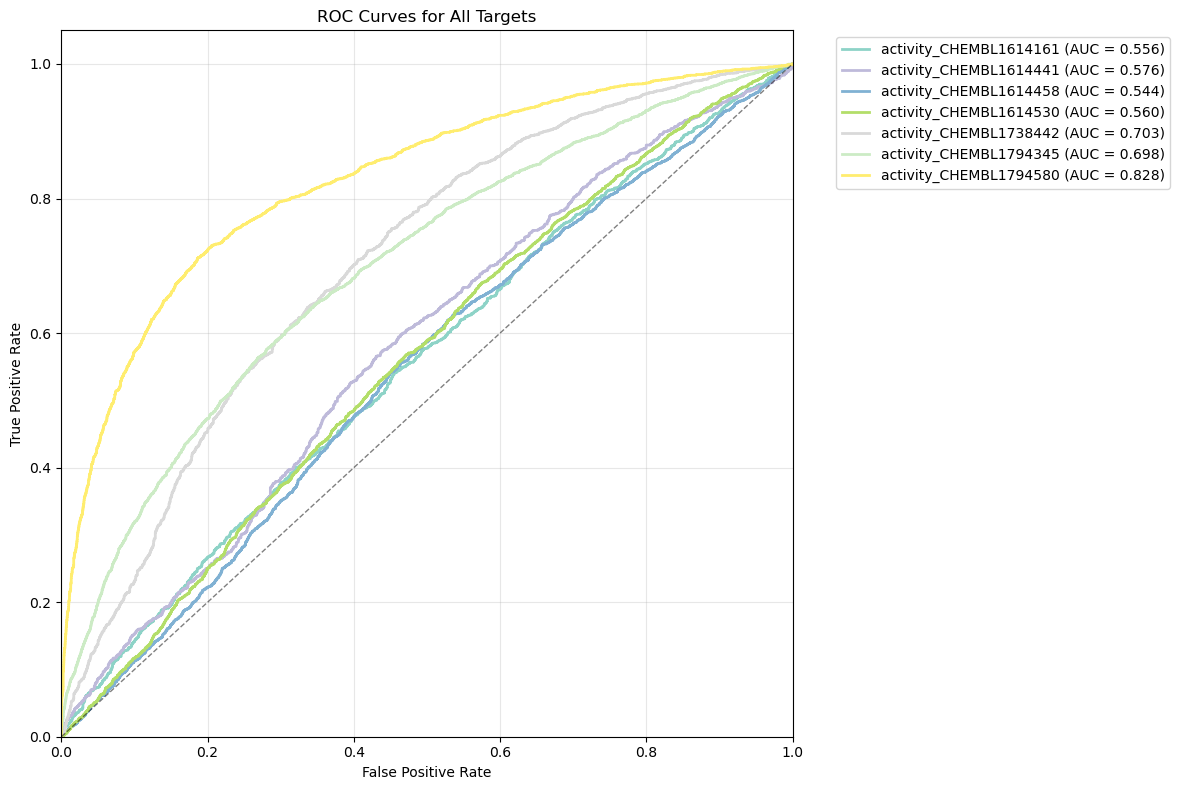

In [74]:
# Create ROC curves plot
plt.figure(figsize=(12, 8))

# Plot ROC curves for each target
colors = plt.cm.Set3(np.linspace(0, 1, len(target_metrics)))

for i, (target_name, metrics) in enumerate(target_metrics.items()):
    plt.plot(
        metrics['fpr'], 
        metrics['tpr'], 
        color=colors[i], 
        lw=2, 
        label=f'{target_name} (AUC = {metrics["roc_auc"]:.3f})'
    )

# Plot diagonal line
plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for All Targets')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Interactive ROC Curves with Plotly (if available)

In [75]:
# Create interactive ROC curves (only if Plotly is available)
if PLOTLY_AVAILABLE:
    fig = go.Figure()
    
    colors = px.colors.qualitative.Set3
    
    for i, (target_name, metrics) in enumerate(target_metrics.items()):
        fig.add_trace(
            go.Scatter(
                x=metrics['fpr'],
                y=metrics['tpr'],
                mode='lines',
                name=f'{target_name} (AUC={metrics["roc_auc"]:.3f})',
                line=dict(color=colors[i % len(colors)], width=2),
                hovertemplate=f'<b>{target_name}</b><br>'
                            f'FPR: %{{x:.3f}}<br>'
                            f'TPR: %{{y:.3f}}<br>'
                            f'AUC: {metrics["roc_auc"]:.3f}<br>'
                            f'<extra></extra>'
            )
        )
    
    # Add diagonal line
    fig.add_trace(
        go.Scatter(
            x=[0, 1],
            y=[0, 1],
            mode='lines',
            name='Random (AUC=0.5)',
            line=dict(color='black', width=1, dash='dash'),
            showlegend=True
        )
    )
    
    fig.update_layout(
        title='ROC Curves for All Targets (Interactive)',
        xaxis_title='False Positive Rate',
        yaxis_title='True Positive Rate',
        xaxis=dict(range=[0, 1]),
        yaxis=dict(range=[0, 1]),
        width=800,
        height=600,
        hovermode='closest'
    )
    
    fig.show()
else:
    print("Plotly not available. Using matplotlib ROC curves above.")
    
    # Create an additional detailed ROC plot with matplotlib
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    
    for i, (target_name, metrics) in enumerate(target_metrics.items()):
        if i >= len(axes):
            break
            
        ax = axes[i]
        ax.plot(metrics['fpr'], metrics['tpr'], 'b-', lw=2, label=f'AUC = {metrics["roc_auc"]:.3f}')
        ax.plot([0, 1], [0, 1], 'k--', lw=1)
        ax.set_xlim([0.0, 1.0])
        ax.set_ylim([0.0, 1.05])
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title(f'{target_name}')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for i in range(len(target_metrics), len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()

## Summary Statistics

In [76]:
# Create summary table
summary_data = []
for target_name, metrics in target_metrics.items():
    summary_data.append({
        'Target': target_name,
        'ROC AUC': f"{metrics['roc_auc']:.4f}",
        'Active Compounds': metrics['n_active'],
        'Inactive Compounds': metrics['n_inactive'],
        'Total Measured': metrics['n_total'],
        'Active Ratio': f"{metrics['n_active']/metrics['n_total']:.3f}"
    })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('ROC AUC', ascending=False)

print("Performance Summary:")
print("=" * 80)
print(summary_df.to_string(index=False))

# Calculate overall statistics
aucs = [metrics['roc_auc'] for metrics in target_metrics.values()]
print(f"\nOverall Statistics:")
print(f"Mean ROC AUC: {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")
print(f"Min ROC AUC: {np.min(aucs):.4f}")
print(f"Max ROC AUC: {np.max(aucs):.4f}")

Performance Summary:
                Target ROC AUC  Active Compounds  Inactive Compounds  Total Measured Active Ratio
activity_CHEMBL1794580  0.8276              2803                6539            9342        0.300
activity_CHEMBL1738442  0.7033              4851                1713            6564        0.739
activity_CHEMBL1794345  0.6982              3337                8768           12105        0.276
activity_CHEMBL1614441  0.5765              1900                1669            3569        0.532
activity_CHEMBL1614530  0.5605              2864                4502            7366        0.389
activity_CHEMBL1614161  0.5556              2131                2346            4477        0.476
activity_CHEMBL1614458  0.5444              2816                5815            8631        0.326

Overall Statistics:
Mean ROC AUC: 0.6380 ± 0.0994
Min ROC AUC: 0.5444
Max ROC AUC: 0.8276


## Distribution of Predictions

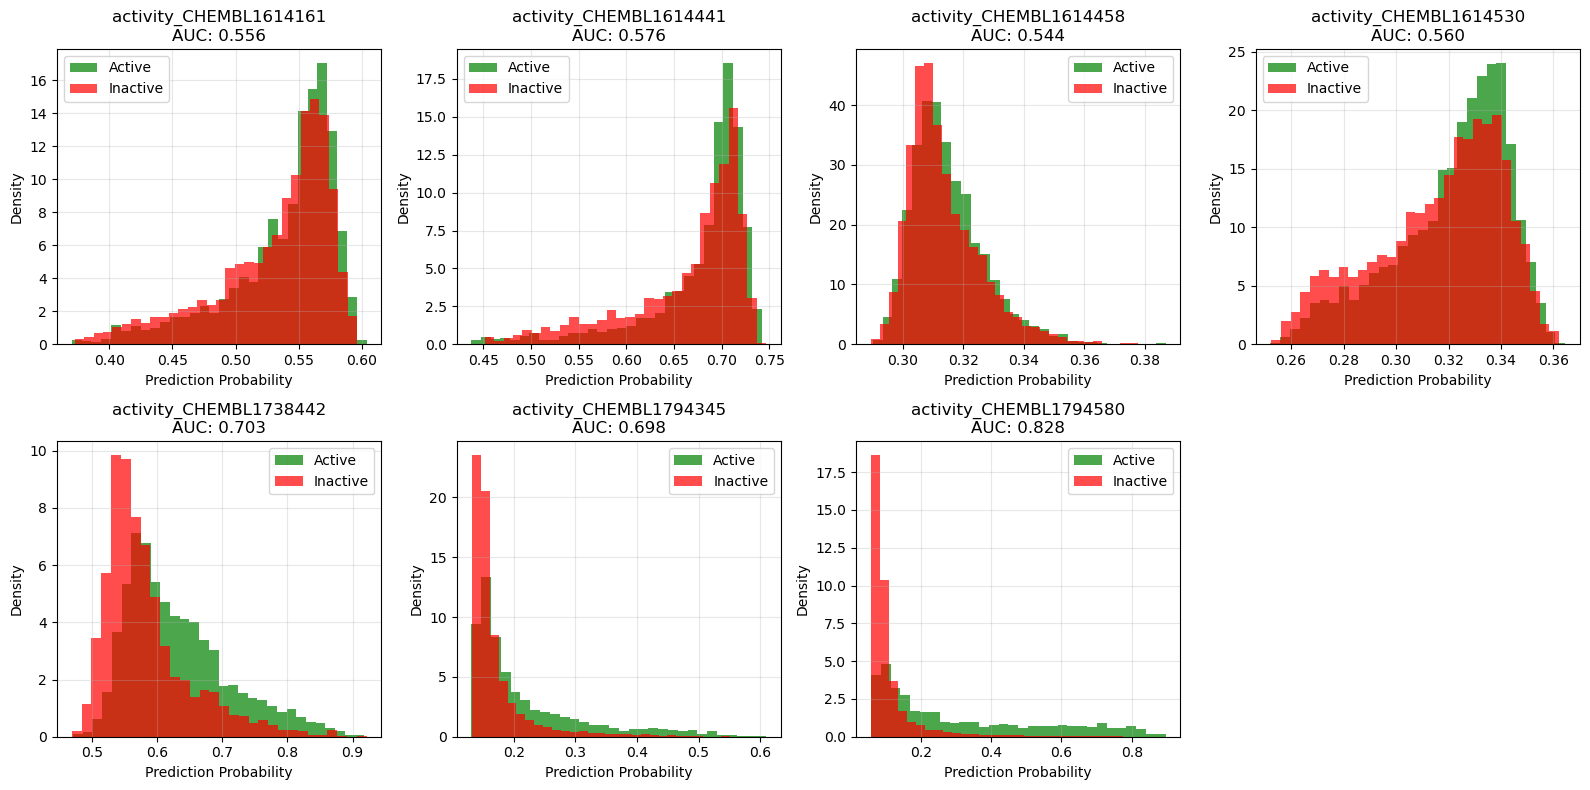

In [77]:
# Plot prediction distributions
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, (target_name, metrics) in enumerate(target_metrics.items()):
    if i >= len(axes):
        break
        
    ax = axes[i]
    
    # Get predictions for active and inactive compounds
    active_preds = metrics['predictions'][metrics['targets'] == 1]
    inactive_preds = metrics['predictions'][metrics['targets'] == 0]
    
    # Plot histograms
    ax.hist(active_preds, bins=30, alpha=0.7, label='Active', color='green', density=True)
    ax.hist(inactive_preds, bins=30, alpha=0.7, label='Inactive', color='red', density=True)
    
    ax.set_xlabel('Prediction Probability')
    ax.set_ylabel('Density')
    ax.set_title(f'{target_name}\nAUC: {metrics["roc_auc"]:.3f}')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for i in range(len(target_metrics), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

## Confusion Matrices

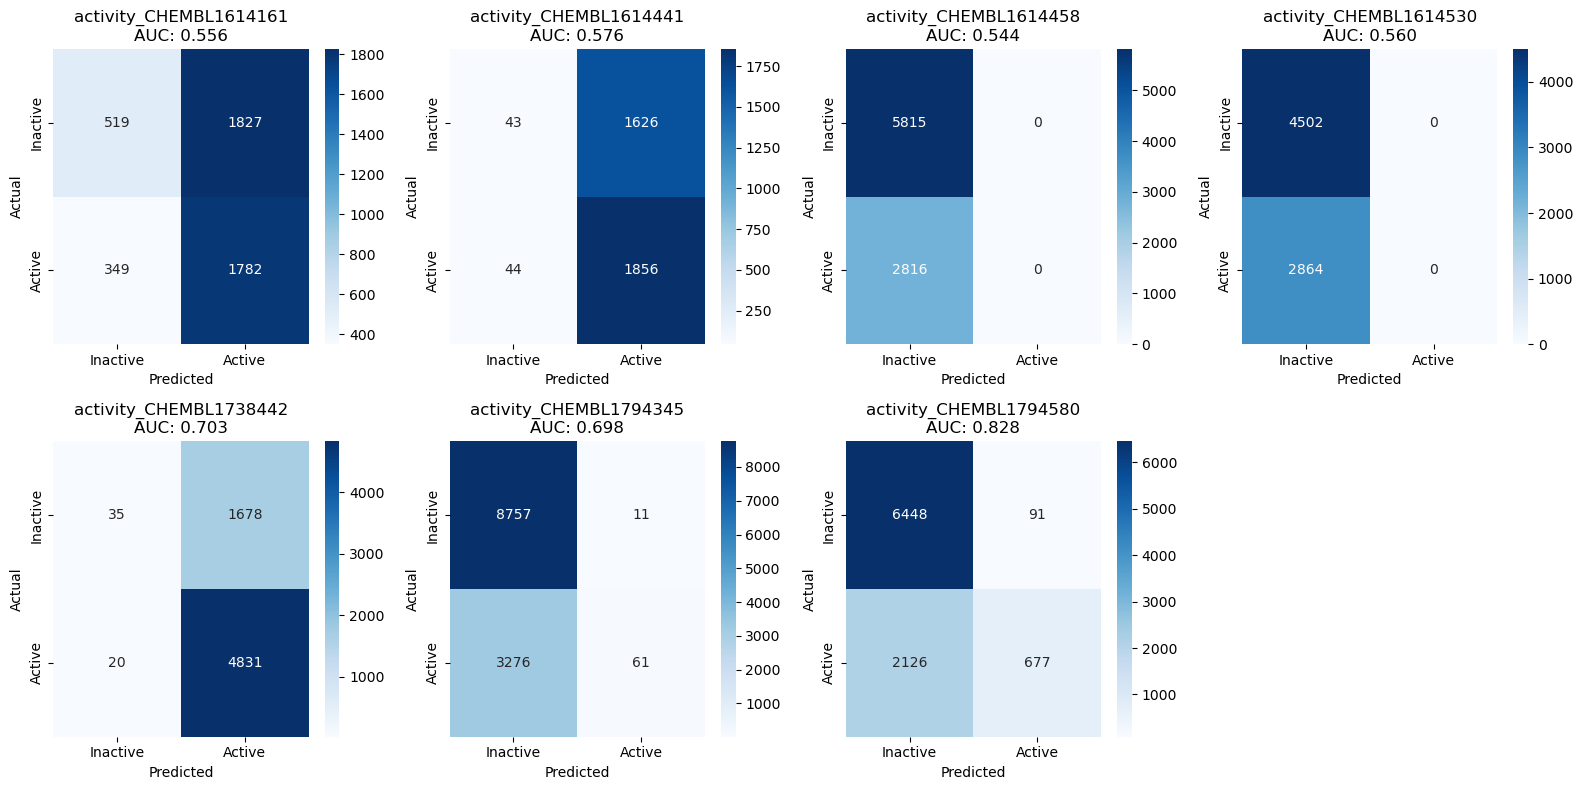

In [78]:
# Plot confusion matrices
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, (target_name, metrics) in enumerate(target_metrics.items()):
    if i >= len(axes):
        break
        
    ax = axes[i]
    
    # Calculate confusion matrix
    predictions_binary = (metrics['predictions'] > 0.5).astype(int)
    cm = confusion_matrix(metrics['targets'], predictions_binary)
    
    # Plot confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Inactive', 'Active'],
                yticklabels=['Inactive', 'Active'])
    
    ax.set_title(f'{target_name}\nAUC: {metrics["roc_auc"]:.3f}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

# Hide unused subplots
for i in range(len(target_metrics), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

## Save Results

In [79]:
# Save results to files
results_dir = Path('model_analysis_results')
results_dir.mkdir(exist_ok=True)

# Save summary table
summary_df.to_csv(results_dir / 'performance_summary.csv', index=False)
print(f"Saved performance summary to {results_dir / 'performance_summary.csv'}")

# Save detailed metrics
detailed_results = {}
for target_name, metrics in target_metrics.items():
    detailed_results[target_name] = {
        'roc_auc': metrics['roc_auc'],
        'n_active': metrics['n_active'],
        'n_inactive': metrics['n_inactive'],
        'n_total': metrics['n_total'],
        'fpr': metrics['fpr'].tolist(),
        'tpr': metrics['tpr'].tolist(),
        'thresholds': metrics['thresholds'].tolist(),
    }

import json
with open(results_dir / 'detailed_metrics.json', 'w') as f:
    json.dump(detailed_results, f, indent=2)
print(f"Saved detailed metrics to {results_dir / 'detailed_metrics.json'}")

print(f"\nAnalysis complete! Results saved to {results_dir}")

Saved performance summary to model_analysis_results/performance_summary.csv
Saved detailed metrics to model_analysis_results/detailed_metrics.json

Analysis complete! Results saved to model_analysis_results
